In [1]:
//Random Forest


import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

num_rows = 20

data = {
    'transaction_id': [f'T{i:03d}' for i in range(num_rows)],
    'transaction_amount': np.round(np.random.uniform(5, 5000, num_rows), 2),
    'transaction_time': [datetime.now() - timedelta(minutes=np.random.randint(1, 1440)) for _ in range(num_rows)],
    'location': np.random.choice(['New York', 'London', 'Paris', 'Tokyo', 'Sydney', 'Berlin', 'Dubai', 'Singapore'], num_rows),
    'merchant_category': np.random.choice(['Groceries', 'Electronics', 'Online_Retail', 'Travel', 'Dining', 'Services'], num_rows),
    'customer_spending_patterns': np.random.choice(['Regular', 'Irregular', 'High_Value'], num_rows),
    'device_information': np.random.choice(['Mobile_App', 'Web_Browser', 'ATM_POS'], num_rows),
    'account_history': np.random.choice(['Old_Active', 'New_Active', 'Dormant'], num_rows),
    'transaction_frequency': np.random.randint(1, 50, num_rows),
    'is_fraudulent': np.random.choice([0, 1], num_rows, p=[0.85, 0.15])
}

df = pd.DataFrame(data)


for i in df.index:
    if df.loc[i, 'is_fraudulent'] == 1:
        if np.random.rand() < 0.7:
            df.loc[i, 'transaction_amount'] = np.round(np.random.uniform(1000, 10000), 2)
        if np.random.rand() < 0.5:
            df.loc[i, 'location'] = np.random.choice(['Moscow', 'Rio de Janeiro', 'Cairo', 'Mumbai', 'Remote_Server'])
        if np.random.rand() < 0.6:
            df.loc[i, 'customer_spending_patterns'] = 'Irregular'
        if np.random.rand() < 0.4:
            df.loc[i, 'account_history'] = 'New_Active'



# Save to a CSV file
df.to_csv('fraud_transactions.csv', index=False)

print("Sample dataset generated and saved to 'fraud_transactions.csv'")
display(df.head(num_rows))

Sample dataset generated and saved to 'fraud_transactions.csv'


,transaction_id,transaction_amount,transaction_time,location,merchant_category,customer_spending_patterns,device_information,account_history,transaction_frequency,is_fraudulent
0,T000,1875.83,2026-04-28 15:32:30.290610,Berlin,Electronics,Regular,ATM_POS,Dormant,15,0
1,T001,4753.82,2026-04-29 01:04:30.290671,London,Travel,Irregular,ATM_POS,New_Active,26,0
2,T002,5363.47,2026-04-28 21:55:30.290685,London,Electronics,Irregular,Mobile_App,New_Active,42,1
3,T003,2995.30,2026-04-28 17:19:30.290694,New York,Services,Regular,ATM_POS,Dormant,13,0
4,T004,784.31,2026-04-29 06:25:30.290702,London,Services,Irregular,ATM_POS,Old_Active,32,0
5,T005,784.19,2026-04-28 17:37:30.290711,Sydney,Services,High_Value,Mobile_App,Dormant,39,0
6,T006,295.13,2026-04-28 22:08:30.290719,London,Electronics,Regular,ATM_POS,Old_Active,49,0
7,T007,4331.55,2026-04-28 17:37:30.290726,Tokyo,Travel,Irregular,Mobile_App,Dormant,32,0
8,T008,3007.57,2026-04-29 00:12:30.290734,Tokyo,Services,Regular,Web_Browser,New_Active,4,0
9,T009,2968.88,2026-04-28 12:27:30.290741,Dubai,Dining,Irregular,ATM_POS,New_Active,30,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('fraud_transactions.csv')

df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['transaction_hour'] = df['transaction_time'].dt.hour

df = df.drop(columns=['transaction_time', 'transaction_id'])

categorical_cols = ['location', 'merchant_category', 'customer_spending_patterns', 'device_information', 'account_history']
numerical_cols = ['transaction_amount', 'transaction_frequency', 'transaction_hour']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('is_fraudulent', axis=1)
y = df_encoded['is_fraudulent']

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # Stratify to maintain class distribution

print("Data loaded and preprocessed successfully.")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
display(X_train.head())

Data loaded and preprocessed successfully.
Training set shape: (14, 19)
Test set shape: (6, 19)


,transaction_amount,transaction_frequency,transaction_hour,location_Dubai,location_London,location_New York,location_Paris,location_Singapore,location_Sydney,location_Tokyo,merchant_category_Electronics,merchant_category_Services,merchant_category_Travel,customer_spending_patterns_Irregular,customer_spending_patterns_Regular,device_information_Mobile_App,device_information_Web_Browser,account_history_New_Active,account_history_Old_Active
10,-1.482431,0.603512,0.836402,False,False,False,False,False,False,True,True,False,False,False,True,False,True,False,True
6,-1.364155,1.595586,1.247747,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True
3,0.340856,-1.380637,0.562172,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False
9,0.324174,0.024802,-0.123404,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
11,1.511809,-0.553908,0.150827,True,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True


Principal Component analysis alogrithm


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['is_fraudulent'] = y.reset_index(drop=True) # Add the target variable for coloring

print("Original number of features:", X.shape[1])
print("Reduced number of features (PCA components):", pca.n_components_)

Original number of features: 19
Reduced number of features (PCA components): 2


Number of components: 2
Explained variance ratio of Principal Components: [0.238286   0.22565081]
Total explained variance: 0.46


,Principal Component 1,Principal Component 2,is_fraudulent
0,-0.704046,-0.955179,0
1,2.495053,-0.385739,0
2,1.214746,1.970737,1
3,-0.314367,-1.361122,0
4,-0.250887,-0.224812,0


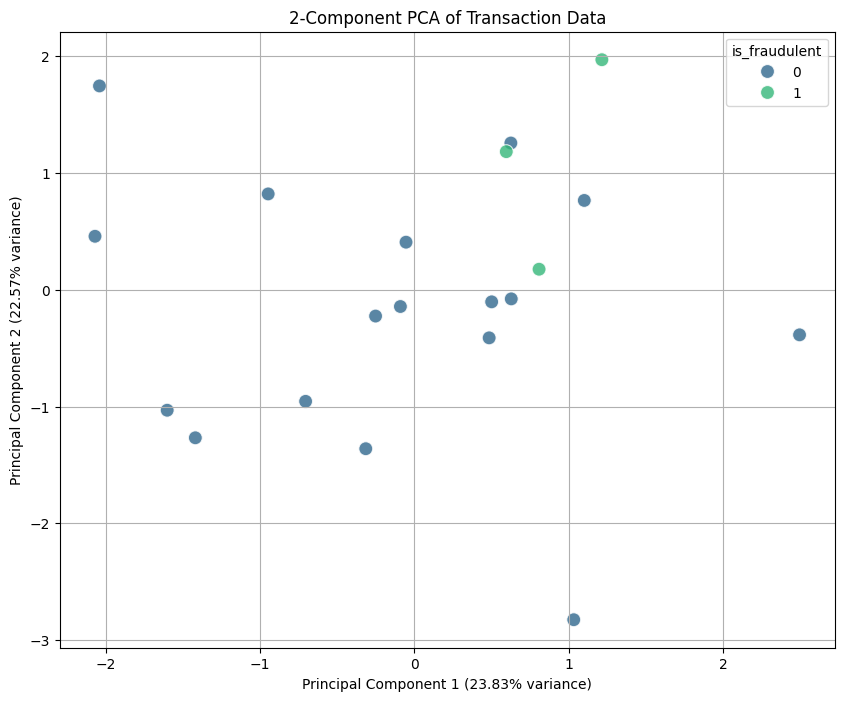

In [10]:
print("Number of components:", pca.n_components_)
print("Explained variance ratio of Principal Components:", pca.explained_variance_ratio_)
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

display(pca_df.head())

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='is_fraudulent',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('2-Component PCA of Transaction Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)
plt.show()

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

print("\nModel Evaluation:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nSample Predictions (Test Set):")
sample_predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Fraud_Probability': np.round(y_pred_proba, 4)
})
display(sample_predictions.head())


Model Evaluation:

Accuracy: 0.8333

Confusion Matrix:
 [[5 0]
 [1 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6


Sample Predictions (Test Set):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Actual,Predicted,Fraud_Probability
0,0,0,0.27
1,0,0,0.09
2,0,0,0.29
3,0,0,0.16
4,1,0,0.39


In [11]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

pca_for_model = PCA(n_components=0.95)
X_train_pca = pca_for_model.fit_transform(X_train)
X_test_pca = pca_for_model.transform(X_test)

print(f"Number of components selected to retain 95% variance: {pca_for_model.n_components_}")

rf_classifier_pca = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_classifier_pca.predict(X_test_pca)
print("\nClassification Report with PCA features:\n", classification_report(y_test, y_pred_pca))

Number of components selected to retain 95% variance: 9

Classification Report with PCA features:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
